# Simulation Based Inference to Remove Sampling Bias - Household Studies


Household infection model with parameters `alpha`, `beta`, `delta`, `mu_inf_SI`, `mu_inf_SC`, `mu_inf_AI`, `mu_inf_AC`, `mu_inf_AA`, `mu_susc_I`, `mu_susc_C`, `mu_protect_acq`, `mu_protect_transm`.

In [1]:
# install dependencies
# import install_requirements

In [2]:
import os

os.environ['KERAS_BACKEND'] = 'tensorflow'

job_array_id = 0  # int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
n_procs = 10  # int(os.environ.get('SLURM_CPUS_PER_TASK', 1))
batch_size = 64
variants = ['alpha', 'omicron']
# name of the scenario, used for saving files
if len(variants) == 2:
    scenario_name = 'pedcov_both_variants'
elif variants[0] == 'alpha':
    scenario_name = f'pedcov'
elif variants[0] == 'omicron':
    scenario_name = f'pedcov_omicron'
else:
    raise ValueError(f"Unknown variant: {variants}")
print('Scenario:', scenario_name)

Scenario: pedcov_both_variants


## Define model and prior

We fix some parameters such that the model becomes identifiable (checked with STAN). We fix the parameters `alpha`.

In [3]:
import pickle
import itertools
from matplotlib import pyplot as plt
from joblib import Parallel, delayed

import numpy as np
import pandas as pd

import keras
import bayesflow as bf

from PedCov.stan import get_stan_posterior
from PedCov.simulator import OutbreakSimulator
#OutbreakSimulator = lambda variant: None
from PedCov.helper_functions import list_of_dicts_to_dict_of_lists, normalize_household_data, sampling_parameter_cis, sampling_parameter_cis_comparison

INFO:bayesflow:Using backend 'tensorflow'
DEBUG:cmdstanpy:found newer exe file, not recompiling
DEBUG:cmdstanpy:found newer exe file, not recompiling
INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /Library/Frameworks/R.framework/Resources
INFO:rpy2.situation:R library path: 
INFO:rpy2.situation:LD_LIBRARY_PATH: 
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.11/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "XPC_SERVICE_NAME" redefined by R and overriding existing variable. Current: "application.com.jetbrains.pycharm.10034226.76192076", R: "0"
  warnings.warn(
/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.11/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/6l/dj45z5dn7zn0djmp1vjb

In [4]:
param_names = {  # comment out parameters that should not be estimated
    #'alpha': r'$\alpha$',
    'beta': r'$\beta$', 'delta': r'$\delta$',
    'mu_inf_SI': r'$\mu_\text{infectiousness}^\text{symptomatic Infant}$', 'mu_inf_SC': r'$\mu_\text{infectiousness}^\text{symptomatic Child}$',
    'mu_inf_AI': r'$\mu_\text{infectiousness}^\text{asymptomatic Infant}$', 'mu_inf_AC': r'$\mu_\text{infectiousness}^\text{asymptomatic Child}$', 'mu_inf_AA': r'$\mu_\text{infectiousness}^\text{asymptomatic Adult}$',
    'mu_susc_I': r'$\mu_\text{susceptibility}^\text{Infant}$', 'mu_susc_C': r'$\mu_\text{susceptibility}^\text{Child}$',
    'mu_protect_acq': r'$\mu_\text{protect}^\text{acq}$', 'mu_protect_transm': r'$\mu_\text{protect}^\text{transm}$'
}

full_name_list = ['alpha', 'beta', 'delta',
                  'mu_inf_SI', 'mu_inf_SC', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
                  'mu_susc_I', 'mu_susc_C',
                  'mu_protect_acq', 'mu_protect_transm']

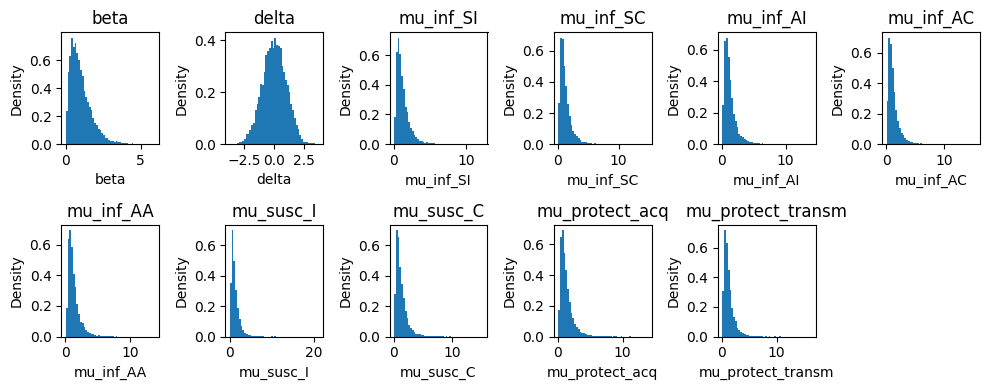

({'variant': 'omicron',
  'variant_id': 1,
  'selection_procedure': 'pedcov',
  'selection_procedure_id': 1},
 {'alpha': 0.001,
  'beta': 1.4871507285536643,
  'delta': 1.433467615529479,
  'mu_inf_SI': 0.268924935107035,
  'mu_inf_SC': 1.5778155476198021,
  'mu_inf_AI': 0.8221479891485294,
  'mu_inf_AC': 0.551516480705876,
  'mu_inf_AA': 1.3737510888488766,
  'mu_susc_I': 1.6499782142605535,
  'mu_susc_C': 0.4914330180830813,
  'mu_protect_acq': 5.077867555076926,
  'mu_protect_transm': 1.3609239906511463})

In [5]:
# define the prior
def meta() -> dict:
    _selection_procedure_id = np.random.choice([0, 1, 2])  # 0 for random, 1 for pedcov, 2 for adult
    _variant = np.random.choice(variants)  # 0 for alpha, 1 for omicron
    return dict(
        variant=_variant,  # alpha or omicron
        variant_id=0 if _variant == 'alpha' else 1,
        selection_procedure=['random', 'pedcov', 'adultcov'][_selection_procedure_id],
        selection_procedure_id=_selection_procedure_id
    )

def prior(variant) -> dict:
    var = 0.7 # was 1 before
    if variant == 'alpha':
        alpha_fixed = 0.001  # fixed for alpha
    elif variant == 'omicron':
        alpha_fixed = 0.01  # fixed for omicron
    else:
        raise ValueError(f"Unknown variant: {variant}")

    params = {
        'alpha': np.random.uniform(0, 0.1) if 'alpha' in param_names.keys() else alpha_fixed,
        'beta': np.random.gamma(shape=2.0, scale=1/2.0) if 'beta' in param_names.keys() else 0.3,
        'delta': np.random.normal(0.0, 1.0) if 'delta' in param_names.keys() else 0.1,
        'mu_inf_SI': np.random.lognormal(0, var) if 'mu_inf_SI' in param_names.keys() else 1.0,
        'mu_inf_SC': np.random.lognormal(0, var) if 'mu_inf_SC' in param_names.keys() else 1.0,
        'mu_inf_AI': np.random.lognormal(0, var) if 'mu_inf_AI' in param_names.keys() else 1.0,
        'mu_inf_AC': np.random.lognormal(0, var) if 'mu_inf_AC' in param_names.keys() else 1.0,
        'mu_inf_AA': np.random.lognormal(0, var) if 'mu_inf_AA' in param_names.keys() else 1.0,
        'mu_susc_I': np.random.lognormal(0, var) if 'mu_susc_I' in param_names.keys() else 1.0,
        'mu_susc_C': np.random.lognormal(0, var) if 'mu_susc_C' in param_names.keys() else 1.0,
        'mu_protect_acq': np.random.lognormal(0, var) if 'mu_protect_acq' in param_names.keys() else 0.8,
        'mu_protect_transm': np.random.lognormal(0, var) if 'mu_protect_transm' in param_names.keys() else 1.0
    }
    return params


def plot_priors(n_samples=10000):
    # Sample from the prior
    samples = {key: np.zeros(n_samples) for key in param_names}
    for i in range(n_samples):
        p = prior("alpha")
        for key in samples:
            samples[key][i] = p[key]

    # Set up subplots
    fig, axes = plt.subplots(2, int(np.ceil(len(param_names) / 2)), figsize=(10, 4), tight_layout=True)
    axes = axes.flatten()

    for idx, key in enumerate(samples):
        data = samples[key]
        ax = axes[idx]

        # Plot histogram
        ax.hist(data, bins=50, density=True)
        ax.set_title(key)
        ax.set_ylabel('Density')
        ax.set_xlabel(key)

    # Remove any empty subplots
    for j in range(len(samples), len(axes)):
        fig.delaxes(axes[j])
    plt.show()

# Execute the plot function
plot_priors()
meta(), prior("alpha")

In [6]:
simulator_alpha = OutbreakSimulator(variant='alpha')
simulator_omicron = OutbreakSimulator(variant='omicron')

In [7]:
#plot_incubation_distribution(simulator_alpha.shapeIncub, simulator_alpha.scaleIncub,
#                             simulator_alpha.shapeIncubAsymp, simulator_alpha.scaleIncubAsymp)
#plot_generation_time_distribution(simulator_alpha.shape_generation_time, simulator_alpha.scale_generation_time)
#plot_delay_distribution(simulator_alpha.delayDist)

In [8]:
%%time
test_params = prior("alpha")
print(test_params)
# test = simulator_alpha(**test_params, return_df=True)
# test['sim_data_df'].head()
# print(test['sim_data_df'].infect_status.value_counts())
# print(test['sim_data'].shape)
#
# test = simulator_omicron(**test_params, return_df=True)
# test['sim_data_df'].head()
# print(test['sim_data_df'].infect_status.value_counts())
# print(test['sim_data'].shape)

{'alpha': 0.001, 'beta': 0.5845181316845767, 'delta': -1.4750019251384636, 'mu_inf_SI': 0.5546211807514492, 'mu_inf_SC': 1.28026398774722, 'mu_inf_AI': 1.3248736008018775, 'mu_inf_AC': 0.5541465800704428, 'mu_inf_AA': 0.8021206135835763, 'mu_susc_I': 1.4686219751623564, 'mu_susc_C': 0.4980565460038029, 'mu_protect_acq': 2.576196198803373, 'mu_protect_transm': 0.7382029111479476}
CPU times: user 67 μs, sys: 3 μs, total: 70 μs
Wall time: 70.8 μs


## Generate training data

In [9]:
num_training_batches = 500
num_validation_sets = 5  # is multiplied by number of possible selection procedures, gives around 1000 datasets
training_data_file = f'models/training_data_{scenario_name}.pickle'
validation_data_file = f'models/valid_data_{scenario_name}.pickle'

In [10]:
@delayed
def simulate_single(generate_valid_data=False, selection_procedure_valid='all') -> dict:
    out = meta()
    out2 = prior(out['variant'])
    if out['variant'] == 'alpha':
        _simulator = simulator_alpha
    else:
        _simulator = simulator_omicron
    out.update(out2)

    if generate_valid_data:  # compute STAN posterior for validation data as well
        out3 = _simulator(selection_procedure=selection_procedure_valid, return_df=True, **out2)

        if selection_procedure_valid == 'all':
            for sp, val in out3.items():
                stan_posterior = get_stan_posterior(val['sim_data_df'], param_names, _simulator,
                                                    alpha=out['alpha'] if 'alpha' not in param_names else None,
                                                    #mu_protect_acq=out['mu_protect_acq'],
                                                    #mu_protect_transm=out['mu_protect_transm'],
                                                    show_progress=False)
                out3[sp].pop('sim_data_df')  # remove the DataFrame, we do not need it anymore
                for p_name in stan_posterior.keys():
                    out3[sp][f'stan_{p_name}'] = stan_posterior[p_name]
            for key in out3['random'].keys():
                out[key] = np.stack((out3['random'][key],
                                     out3['pedcov'][key],
                                     out3['adultcov'][key]), axis=0)
            # repeat entries
            out['variant'] = [[out['variant']], [out['variant']], [out['variant']]]
            out['variant_id'] = [[out['variant_id']], [out['variant_id']], [out['variant_id']]]
            out['selection_procedure'] = [['random'], ['pedcov'], ['adultcov']]
            out['selection_procedure_id'] = [[0], [1], [2]]  # 0 for random, 1 for pedcov, 2 for adultcov
            for p in full_name_list:
                out[p] = [[out[p]], [out[p]], [out[p]]]
            return out
        else:
            # just one selection procedure
            out['selection_procedure'] = selection_procedure_valid
            out['selection_procedure_id'] = 0 if selection_procedure_valid == 'random' else 1 if selection_procedure_valid == 'pedcov' else 2
            stan_posterior = get_stan_posterior(out3['sim_data_df'], param_names, _simulator,
                                                        alpha=out['alpha'] if 'alpha' not in param_names else None,
                                                        #mu_protect_acq=out['mu_protect_acq'],
                                                        #mu_protect_transm=out['mu_protect_transm'],
                                                        show_progress=False)
            out3.pop('sim_data_df')  # remove the DataFrame, we do not need it anymore
            for p_name in stan_posterior.keys():
                out3[f'stan_{p_name}'] = stan_posterior[p_name]
    else:
        out3 = _simulator(selection_procedure=out['selection_procedure'], **out2)

    out.update(out3)
    for p in full_name_list:
        out[p] = [out[p]]
    return out

In [11]:
# # test stan and simulations
# # stan uses 4 cpus per job, so we can use 1/4 of the available cpus
# test_data = Parallel(n_jobs=10 // 4, verbose=1)(simulate_single(generate_valid_data=True,
#                                                                 selection_procedure_valid='random') for _ in range(2))
# test_data = list_of_dicts_to_dict_of_lists(test_data)
# test_data_random = test_data.copy()
# select_id = test_data_random['selection_procedure'] == 'random'
# for k in test_data_random.keys():
#     test_data_random[k] = test_data_random[k][select_id.flatten()]
#
# stan_posterior_samples = {p: test_data_random[f'stan_{p}'] for p in param_names.keys()}
# fig = bf.diagnostics.recovery(stan_posterior_samples, test_data_random, variable_names=list(param_names.values()))
# fig.savefig('plots/test_recovery.png')
# fig = bf.diagnostics.calibration_ecdf(stan_posterior_samples, test_data_random, variable_names=list(param_names.values()), difference=True)
# fig.savefig('plots/test_ecdf.png')
# exit()

In [12]:
if os.path.exists(validation_data_file):
    # load simulation PedCov
    with open(validation_data_file, 'rb') as f:
        validation_data = pickle.load(f)
    try:
        with open(training_data_file, 'rb') as f:
            training_data = pickle.load(f)
    except FileNotFoundError:
        training_data = None
else:
    training_data = Parallel(n_jobs=n_procs, verbose=1)(simulate_single() for _ in range(batch_size * num_training_batches))
    training_data = list_of_dicts_to_dict_of_lists(training_data)
    with open(training_data_file, 'wb') as f:
        pickle.dump(training_data, f)

    # stan uses 4 cpus per job, so we can use 1/4 of the available cpus
    validation_data = Parallel(n_jobs=n_procs // 4, verbose=1)(simulate_single(generate_valid_data=True) for _ in range(batch_size * num_validation_sets))
    validation_data = list_of_dicts_to_dict_of_lists(validation_data)
    for key in validation_data.keys():  # concatenate the validation data for the selection procedures
        validation_data[key] = np.concatenate(validation_data[key], axis=0)
    with open(validation_data_file, 'wb') as f:
        pickle.dump(validation_data, f)
    exit()

# bring into same shape as training data
validation_data['variant'] = validation_data['variant'].flatten()
validation_data['variant_id'] = validation_data['variant_id'].flatten()
validation_data['selection_procedure'] = validation_data['selection_procedure'].flatten()
validation_data['selection_procedure_id'] = validation_data['selection_procedure_id'].flatten()

# get all random selection procedure data
validation_data_random = validation_data.copy()
select_id = validation_data_random['selection_procedure'] == 'random'
for k in validation_data_random.keys():
    validation_data_random[k] = validation_data_random[k][select_id.flatten()]

validation_data_pedcov = validation_data.copy()
select_id = validation_data_pedcov['selection_procedure'] == 'pedcov'
for k in validation_data_pedcov.keys():
    validation_data_pedcov[k] = validation_data_pedcov[k][select_id.flatten()]

validation_data_adultcov = validation_data.copy()
select_id = validation_data_adultcov['selection_procedure'] == 'adultcov'
for k in validation_data_adultcov.keys():
    validation_data_adultcov[k] = validation_data_adultcov[k][select_id.flatten()]

if training_data is not None:
    print(f"Training data shape: {training_data['sim_data'].shape}")
print(f"Validation data shape: {validation_data['sim_data'].shape}")
print(f"Validation data Random: {validation_data_random['sim_data'].shape[0]}")
print(f"Validation data PedCov: {validation_data_pedcov['sim_data'].shape[0]}")
print(f"Validation data AdultCov: {validation_data_adultcov['sim_data'].shape[0]}")

Validation data shape: (960, 128, 8, 11)
Validation data Random: 320
Validation data PedCov: 320
Validation data AdultCov: 320


In [13]:
colors = [  # colorblind safe colors
    "#4E79A7",  # blue
    "#F28E2B",  # orange
    "#E15759",  # red
    "#76B7B2",  # teal
    "#59A14F",  # green
    "#EDC948",  # yellow
    "#B07AA1",  # purple
    "#FF9DA7",  # pink
    "#9C755F",  # brown
    "#BAB0AC",  # gray (neutral)
    "#8CD17D",  # light green
    "#FABFD2",  # light pink
]

titles = {
    'random': 'Random Selection Procedure',
    'pedcov': 'Child Selection Procedure',
    'adultcov': 'Adult Selection Procedure'
}

stacked = True  # whether to stack the ECDFs or not

Validation data shape: random


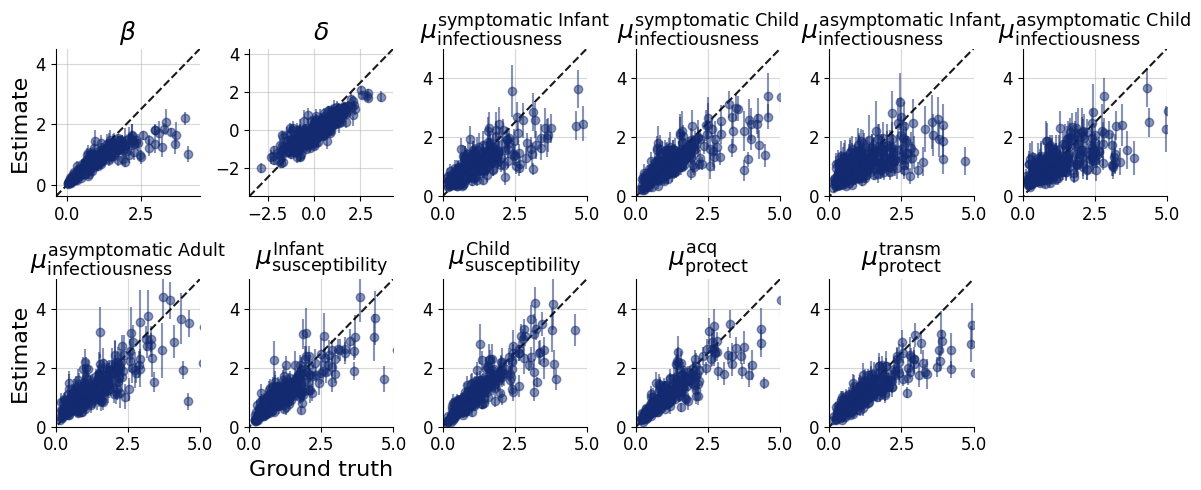

Validation data shape: pedcov


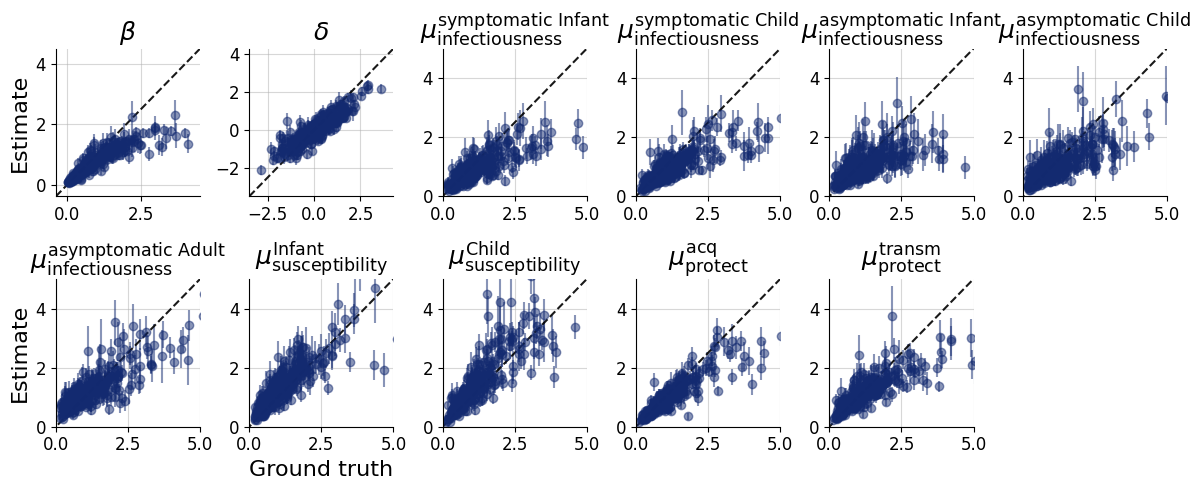

Validation data shape: adultcov


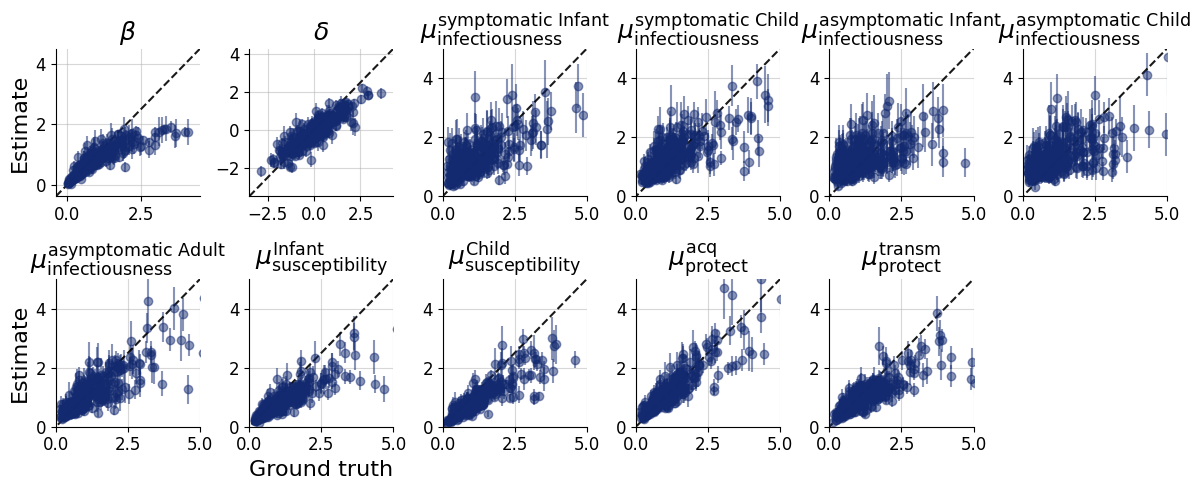

In [14]:
for vd in [validation_data_random, validation_data_pedcov, validation_data_adultcov]:
    print(f"Validation data shape: {vd['selection_procedure'][0]}")
    stan_posterior_samples = {p: vd[f'stan_{p}'] for p in param_names.keys()}

    fig = bf.diagnostics.recovery(stan_posterior_samples, vd, variable_names=list(param_names.values()),
                                  add_corr=False, figsize=(12, 5))
    ax = fig.get_axes()
    for i, a in enumerate(ax):
        if i != 7:
            a.set_xlabel("")
        if i > 1:
            a.set_xlim(0, 5)
            a.set_ylim(0, 5)
    plt.tight_layout()
    #fig.savefig(f'plots/{scenario_name}_recovery_stan_{vd["selection_procedure"][0]}.pdf', bbox_inches='tight')
    plt.show()

Validation data shape: random


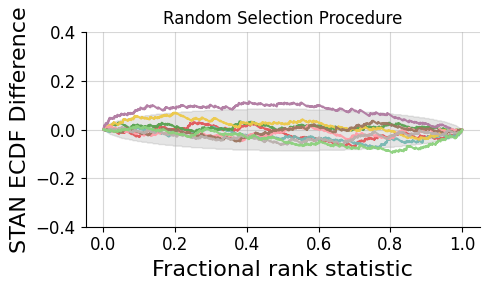

Validation data shape: pedcov


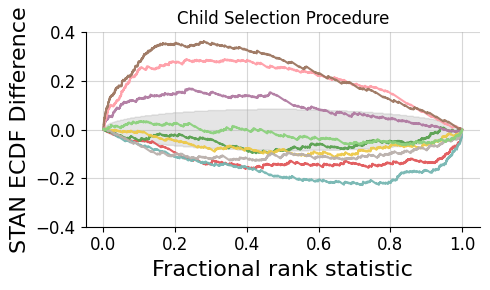

Validation data shape: adultcov


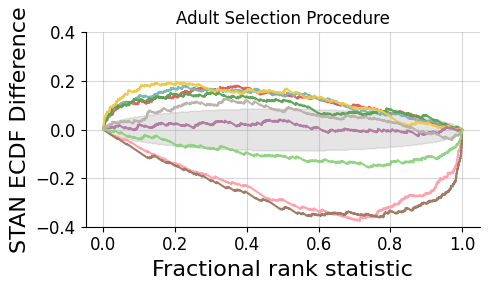

In [15]:
for a_i, vd in enumerate([validation_data_random, validation_data_pedcov, validation_data_adultcov]):
    print(f"Validation data shape: {vd['selection_procedure'][0]}")
    stan_posterior_samples = {p: vd[f'stan_{p}'] for p in param_names.keys()}

    fig = bf.diagnostics.calibration_ecdf(stan_posterior_samples, vd, variable_names=list(param_names.values()),
                                          stacked=stacked, difference=True, figsize=(12, 5) if not stacked else (5, 3))
    ax = fig.get_axes()
    for i, a in enumerate(ax):
        a.get_legend().remove()
        if not stacked:
            if i != 7:
                a.set_xlabel("")
        else:
            lines = a.get_lines()
            for idx, line in enumerate(lines):
                if list(param_names.keys())[idx] in ['beta', 'delta']:
                    line.remove()
                line.set_color(colors[idx])
                line.set_label(f'{list(param_names.values())[idx]}')
            #a.legend(ncols=5, loc='lower center', bbox_to_anchor=(0.5, -0.9))
        a.set_ylim(-0.4, 0.4)
        a.set_title(titles[vd['selection_procedure'][0]])
        a.set_ylabel("STAN ECDF Difference")
    plt.tight_layout()
    #fig.savefig(f'plots/{scenario_name}_ecdf_stan_{vd["selection_procedure"][0]}.pdf', bbox_inches='tight')
    #fig.savefig(f'plots/{scenario_name}_ecdf_legend.pdf', bbox_inches='tight')
    plt.show()

## Neural Posterior Estimation

In [16]:
if len(variants) == 1:
    adapter = (
        bf.adapters.Adapter()
        .drop(['selection_procedure', 'variant'])  # drop strings
        .to_array()
        .one_hot('selection_procedure_id', num_classes=3)  # must be before convert_dtype
        .convert_dtype(from_dtype="float64", to_dtype="float32")

        .constrain('beta', lower=0, inclusive='none', method="softplus")  # standard
        .constrain([k for k in list(param_names.keys()) if k != 'delta' and k != 'beta'], lower=0, inclusive='none', method="exp")
        .concatenate(list(param_names.keys()), into="inference_variables")

        .rename('selection_procedure_id', to_key="inference_conditions")

        .rename('sim_data', to_key="summary_variables")

        .broadcast("inference_conditions", to="summary_variables", expand=(1,2))
        .concatenate(["summary_variables", "inference_conditions"], into="summary_variables")
    )
else:
    adapter = (
        bf.adapters.Adapter()
        .drop(['selection_procedure', 'variant'])  # drop strings
        .to_array()
        .one_hot('selection_procedure_id', num_classes=3)  # must be before convert_dtype
        .one_hot('variant_id', num_classes=2)  # must be before convert_dtype
        .convert_dtype(from_dtype="float64", to_dtype="float32")

        .constrain('beta', lower=0, inclusive='none', method="softplus")  # standard
        .constrain([k for k in list(param_names.keys()) if k != 'delta' and k != 'beta'], lower=0, inclusive='none', method="exp")
        .concatenate(list(param_names.keys()), into="inference_variables")

        .concatenate(['selection_procedure_id', 'variant_id'], into="inference_conditions")

        .rename('sim_data', to_key="summary_variables")

        # add inference conditions to summary variables
        .broadcast("inference_conditions", to="summary_variables", expand=(1,2))
        .concatenate(["summary_variables", "inference_conditions"], into="summary_variables")
    )

In [17]:
from bayesflow.utils.serialization import serializable

@serializable("bayesflow.networks")
class DoubleSummaryNetwork(bf.networks.SummaryNetwork):
    def __init__(self, inner_network, outer_network, name=None, **kwargs):
        super().__init__(**kwargs)
        self.name = 'inner_' + inner_network.name + '_outer_' + outer_network.name if name is None else name
        self.inner_network = inner_network  # operates over elements
        self.outer_network = outer_network  # operates over observations

    def call(self, x, training: bool = False, **kwargs):
        b_size, n_outer_obs, n_inner_obs = keras.ops.shape(x)[:3]

        # Flatten to combine batch and outer observation dimensions
        x_flat = keras.ops.reshape(x, (b_size * n_outer_obs, n_inner_obs, *keras.ops.shape(x)[3:]))

        # Apply the inner network to each element in the outer observation
        inner_output = self.inner_network(x_flat, training=training, **kwargs)

        # Reshape back to (b_size, n_outer_obs, inner_output_dim)
        inner_output = keras.ops.reshape(inner_output, (b_size, n_outer_obs, *keras.ops.shape(inner_output)[1:]))

        # Apply the outer network to the inner outputs
        outer_output = self.outer_network(inner_output, training=training, **kwargs)
        return outer_output


    def get_config(self):
        config = super().get_config()
        config.update({
            "inner_network": self.inner_network,
            "outer_network": self.outer_network
        })
        return config

In [18]:
%%time
job_array_id = 14  # best model with normalizing flows is 14
model_id_list = itertools.product([0, 1, 2], [8, 16, 24, 32, 40], [16, 24, 32, 40])
nrmse_list = []
calibration_list = []
model_list = []
sum_i = 0  # transformer summary
for net_id, (inf_i, in_summary_dim, out_summary_dim) in enumerate(model_id_list):
    if net_id != job_array_id:
        continue
    if inf_i == 0:
        epochs = 100  # coupling flow
    elif inf_i == 1:
        epochs = 300  # flow matching
        continue
    elif inf_i == 2:
        epochs = 300  # consistency model
        continue
    else:
        raise ValueError(f"Unknown inference network index: {inf_i}")

    summary_network = [
        DoubleSummaryNetwork(
             inner_network=bf.networks.TimeSeriesNetwork(summary_dim=in_summary_dim, dropout=0.1, recurrent_dim=32),
             outer_network=bf.networks.SetTransformer(summary_dim=out_summary_dim, dropout=0.1),
             name=f'transformer_time_series'
        ),
        DoubleSummaryNetwork(
             inner_network=bf.networks.TimeSeriesNetwork(summary_dim=in_summary_dim, dropout=0.1, recurrent_dim=32),
             outer_network=bf.networks.DeepSet(summary_dim=out_summary_dim, dropout=0.1,
                                               mlp_widths_equivariant=(128, 128)),
             name=f'deep_set_time_series'
        )
    ][sum_i]

    inference_network = [bf.networks.CouplingFlow(depth=7, subnet_kwargs={"dropout": 0.1}, transform='spline'),
                         bf.networks.FlowMatching(subnet_kwargs={"dropout": 0.1}, use_optimal_transport=True,
                                                  integrate_kwargs={'method': 'rk45', 'steps': 'adaptive'}),
                         bf.networks.ConsistencyModel(epochs*num_training_batches),
                         ][inf_i]

    model_name = (f'{scenario_name}_{["transformer", "deep_set"][sum_i]}'
                  f'_{["coupling_flow", "flow_matching", "consistency_model"][inf_i]}'
                  f'_{in_summary_dim}_{out_summary_dim}.keras')

    workflow = bf.BasicWorkflow(
        adapter=adapter,
        summary_network=summary_network,
        inference_network=inference_network
    )

    model_path = f'models/{model_name}'
    print(model_path)
    if os.path.exists(model_path):
        workflow.approximator = keras.saving.load_model(filepath=model_path)
    else:
        history = workflow.fit_offline(
            data=training_data,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=validation_data,
        )
        workflow.approximator.save(filepath=model_path)

    # diagnostics = workflow.compute_default_diagnostics(test_data=validation_data, num_samples=300)
    # if not np.isnan(diagnostics.loc['NRMSE'].mean()):
    #     nrmse_list.append(diagnostics.loc['NRMSE'].mean())
    #     calibration_list.append(diagnostics.loc['Calibration Error'].mean())
    #     model_list.append(model_name)

models/pedcov_both_variants_transformer_coupling_flow_32_32.keras
CPU times: user 3.5 s, sys: 957 ms, total: 4.46 s
Wall time: 2.71 s


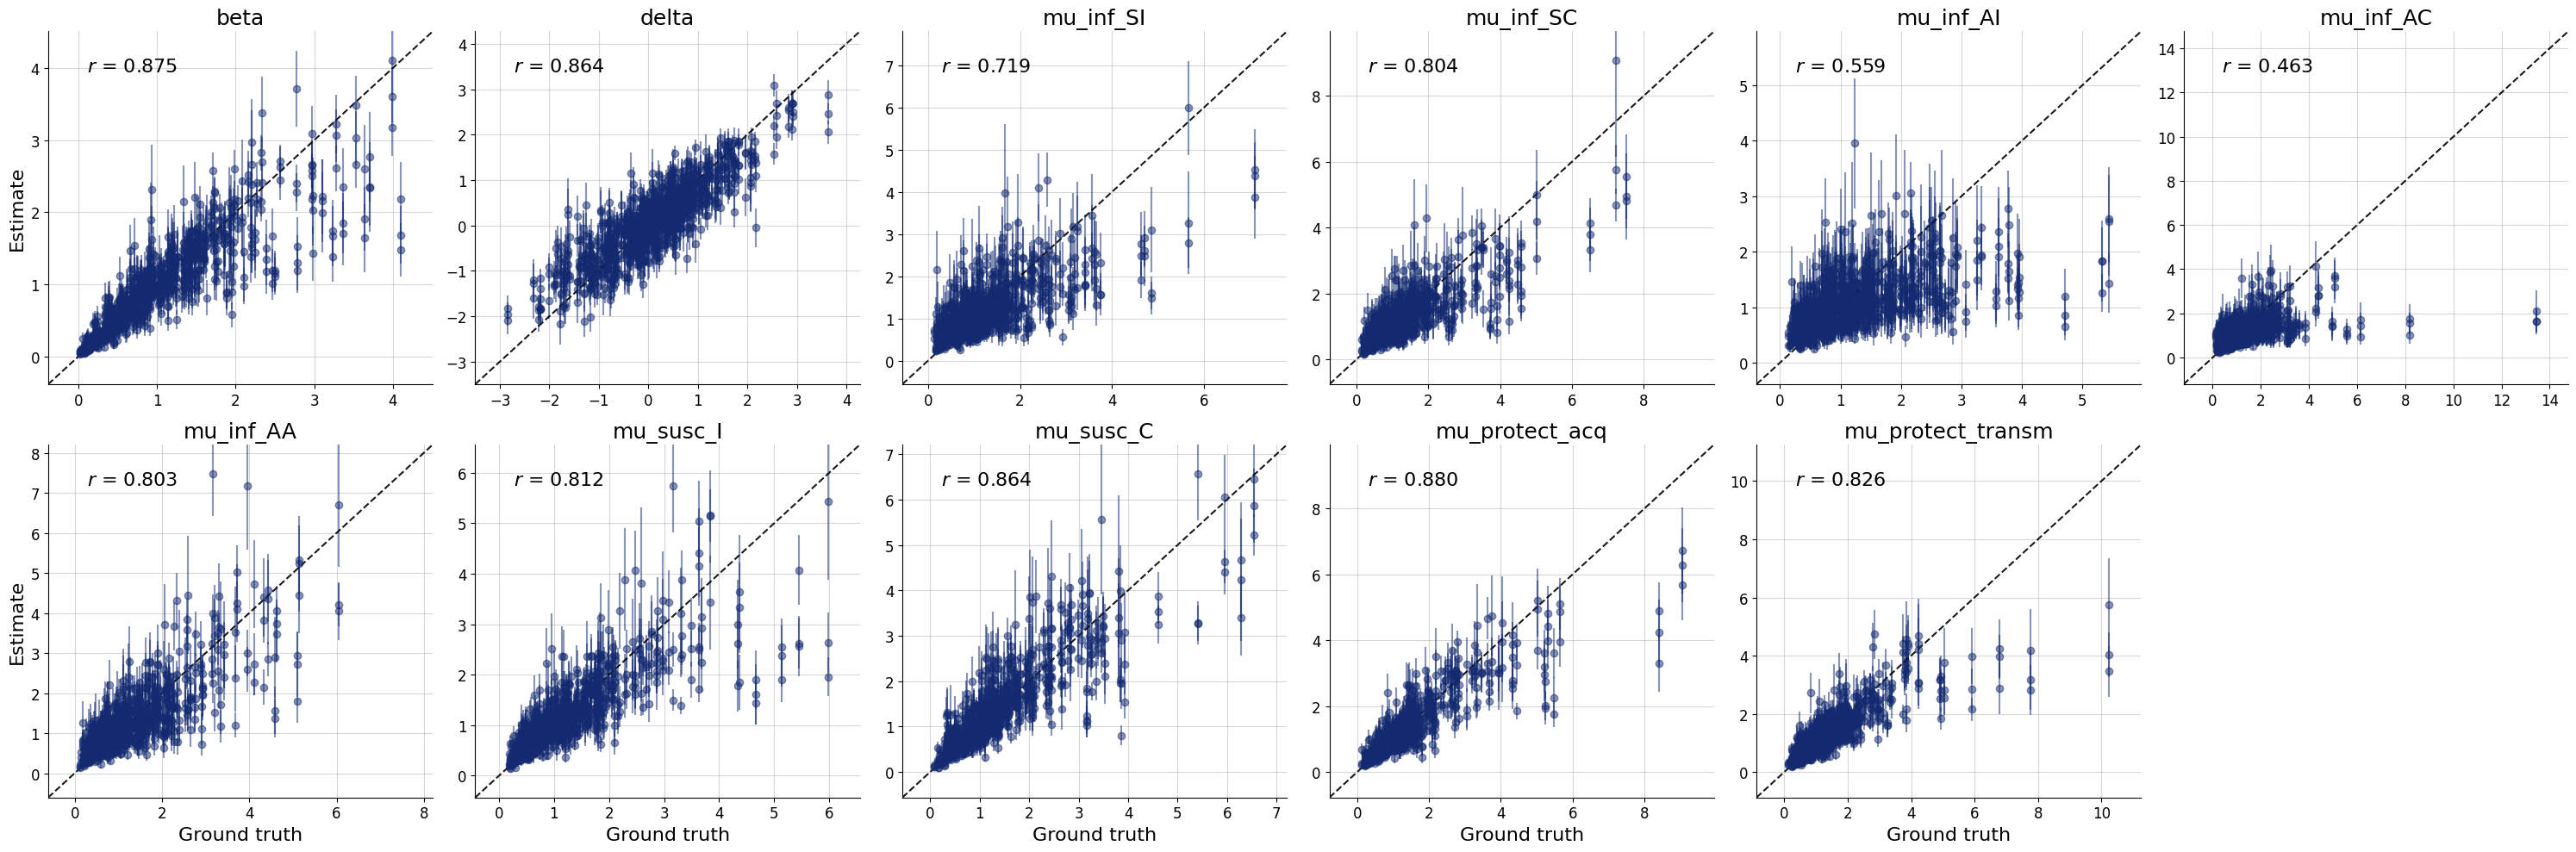

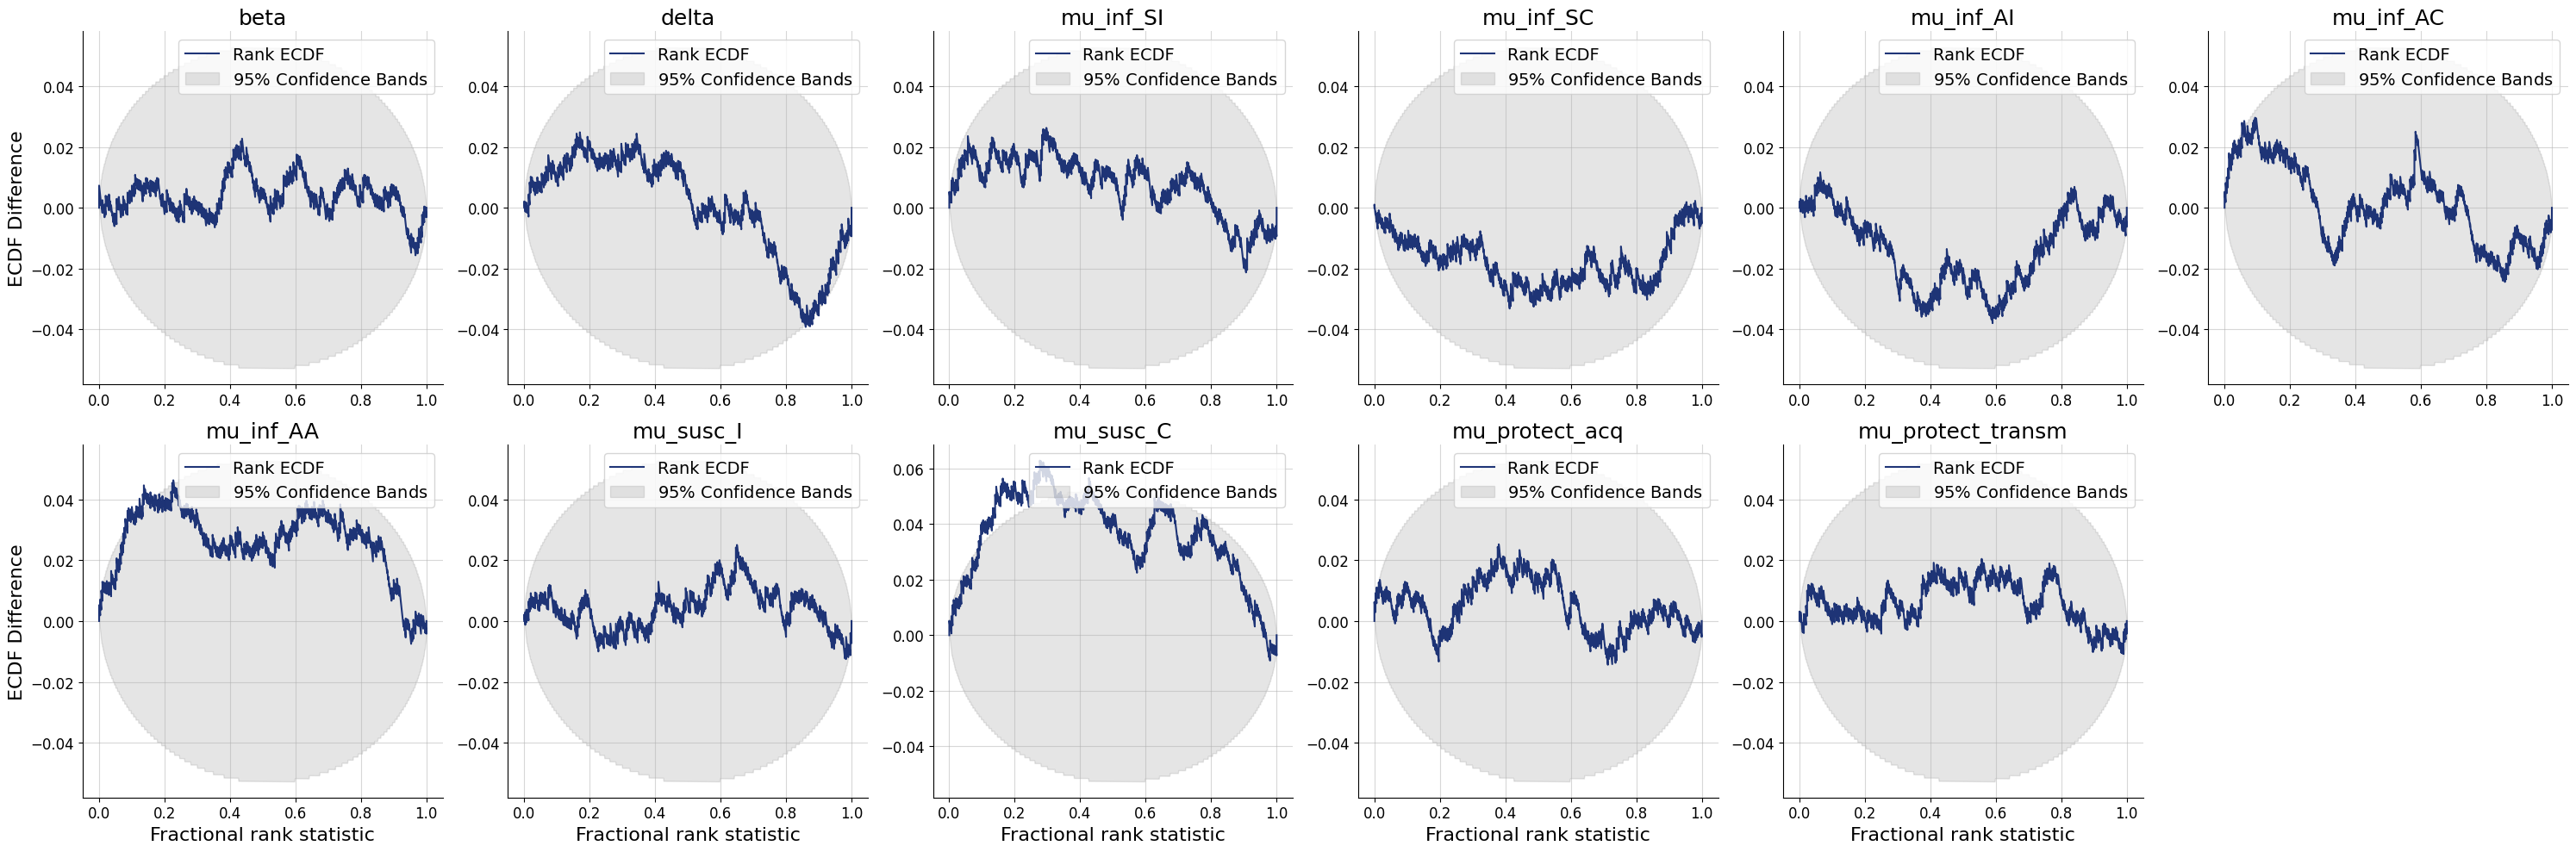

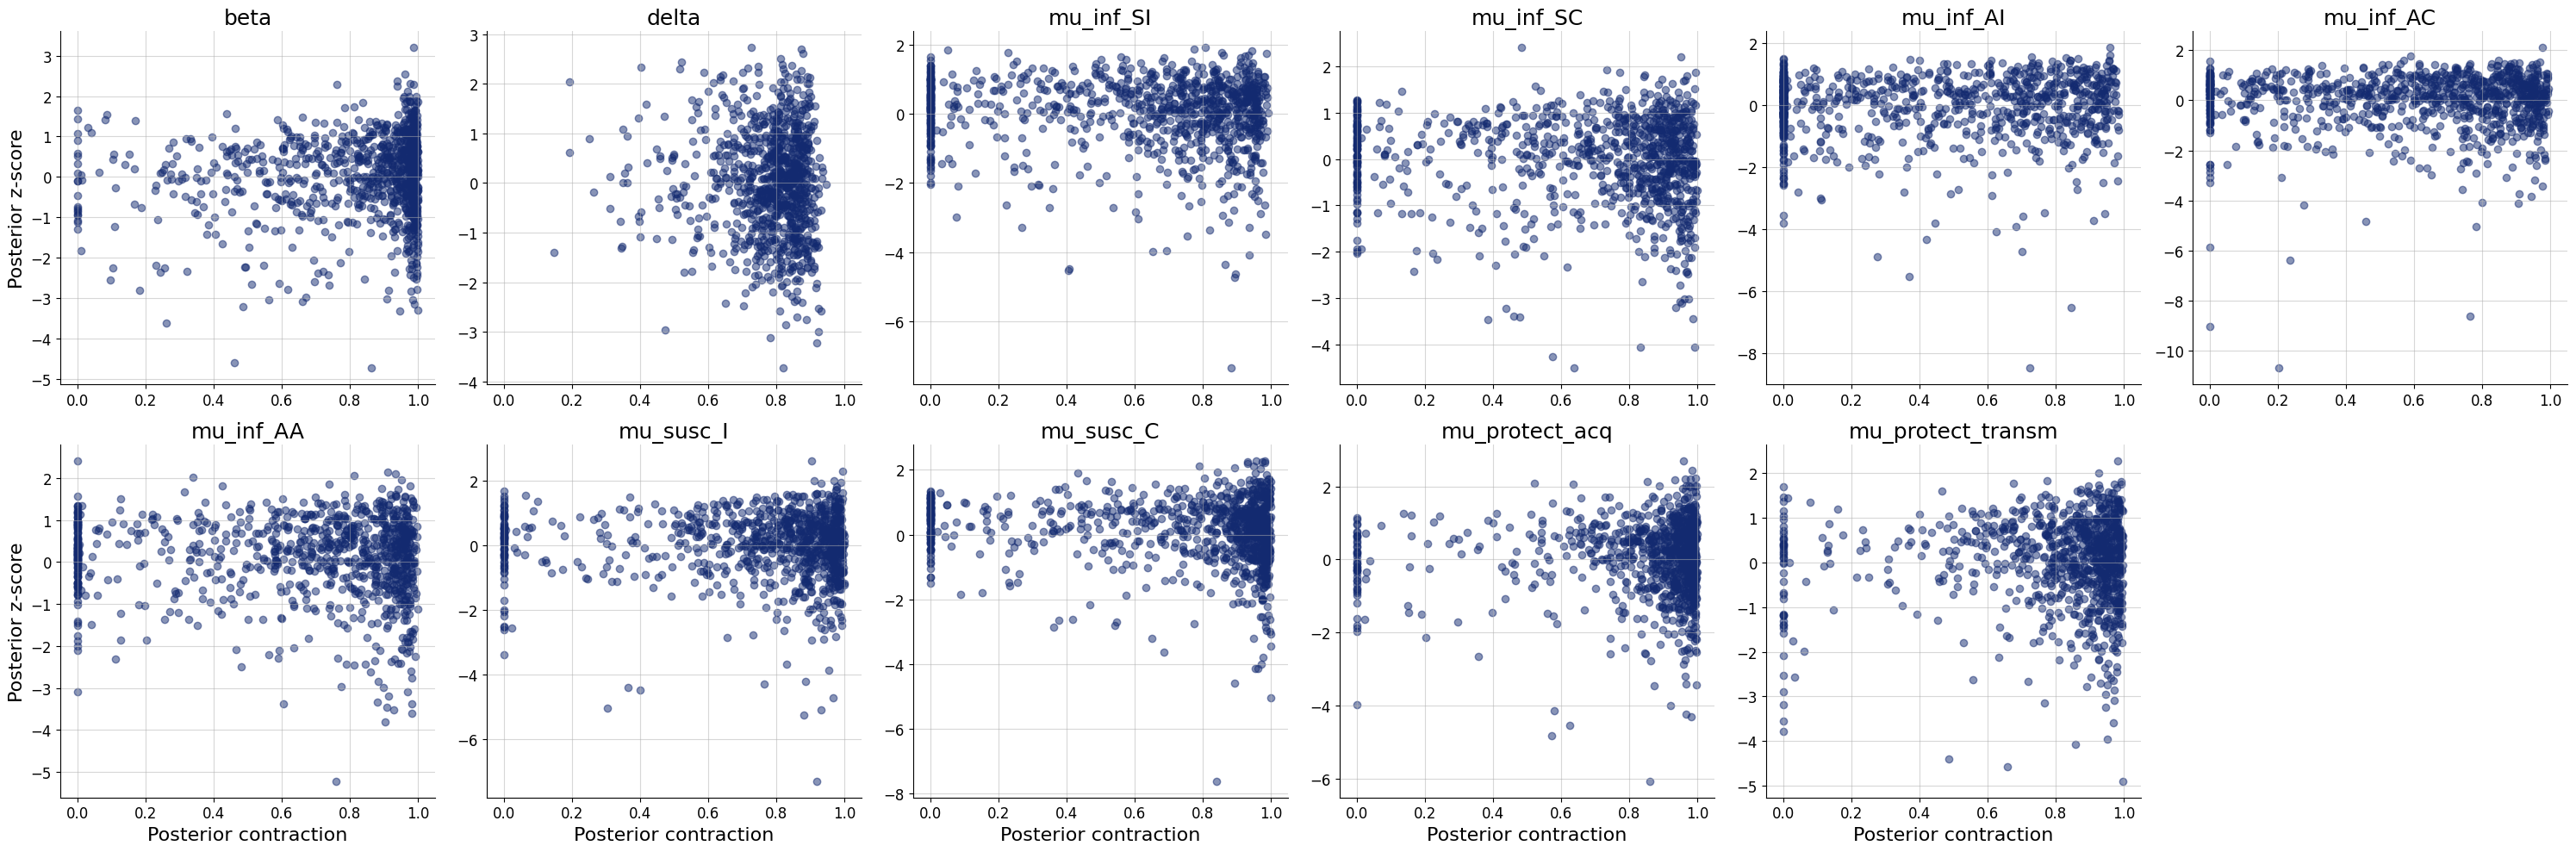

In [19]:
diagnostics = workflow.plot_default_diagnostics(test_data=validation_data, num_samples=300,
                                                calibration_ecdf_kwargs={'difference': True})
# diagnostics['losses'].savefig(f'plots/{scenario_name}_losses_{model_name}.pdf', bbox_inches='tight')
# diagnostics['recovery'].savefig(f'plots/{scenario_name}_recovery_{model_name}.pdf', bbox_inches='tight')
# diagnostics['calibration_ecdf'].savefig(f'plots/{scenario_name}_ecdf_{model_name}.pdf', bbox_inches='tight')

In [20]:
# from PedCov.helper_functions import find_best_model_by_rank_sum, find_best_model_by_normalized_avg
#
# best_model_idx = find_best_model_by_normalized_avg(nrmse_list, calibration_list)
# print(f"Best model (normalized average) is {model_list[best_model_idx]}")
# best_model_idx = find_best_model_by_rank_sum(nrmse_list, calibration_list)
# print(f"Best model (rank sum) is {model_list[best_model_idx]}")
# print(f"Best model (NRMSE): {model_list[np.argmin(nrmse_list)]}")
# print(f"Best model (Calibration Error): {model_list[np.argmin(calibration_list)]}")

# Both variants
# Best model (normalized average) is pedcov_both_variants_transformer_coupling_flow_32_32.keras (14)
# Best model (rank sum) is pedcov_both_variants_transformer_coupling_flow_32_32.keras (14)
# Best model (NRMSE): pedcov_both_variants_transformer_coupling_flow_32_32.keras (14)
# Best model (Calibration Error): pedcov_both_variants_transformer_coupling_flow_8_24.keras (1)

# Simulation Study on Validation Data

Validation data shape: random


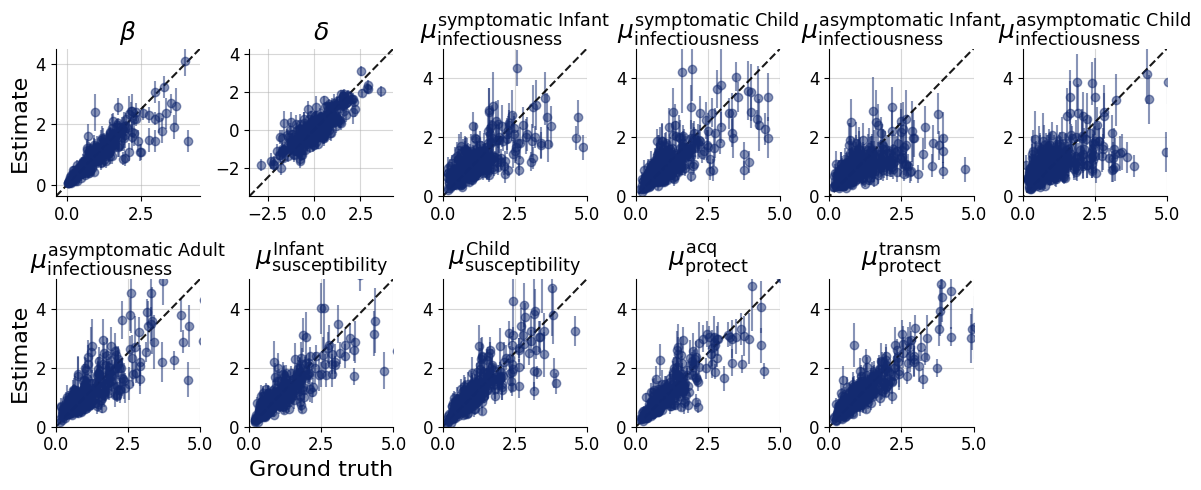

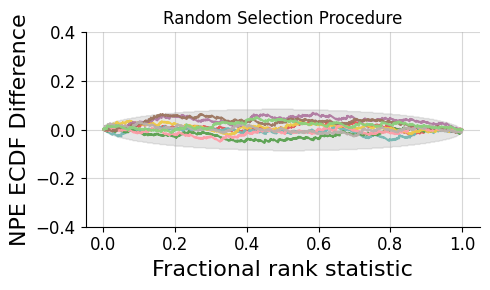

Validation data shape: pedcov


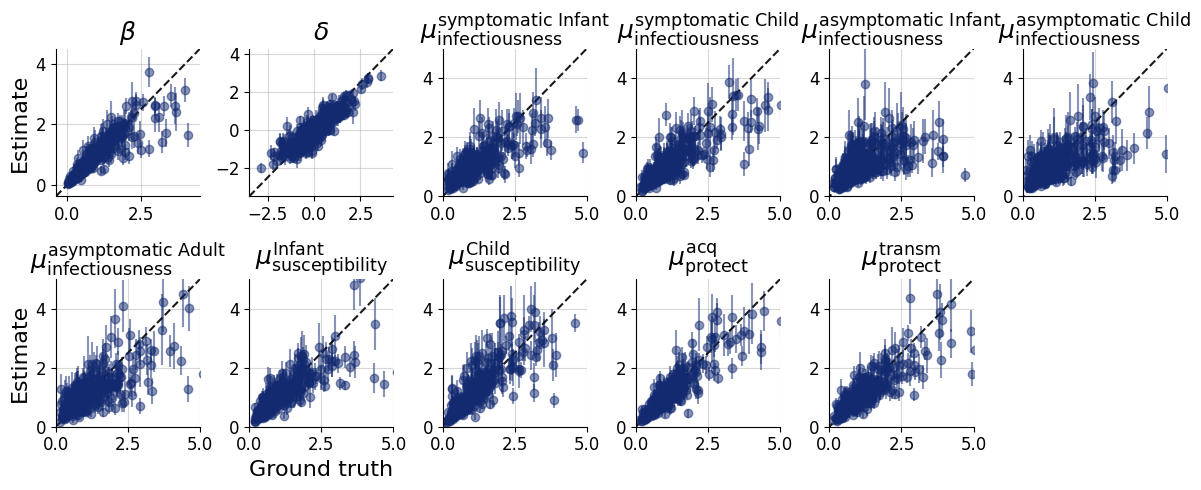

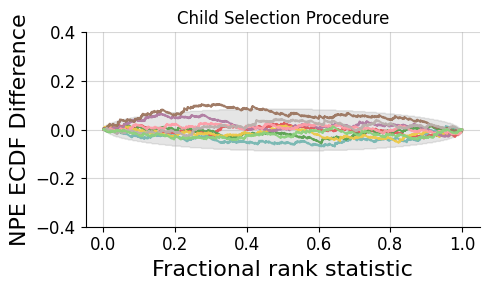

Validation data shape: adultcov


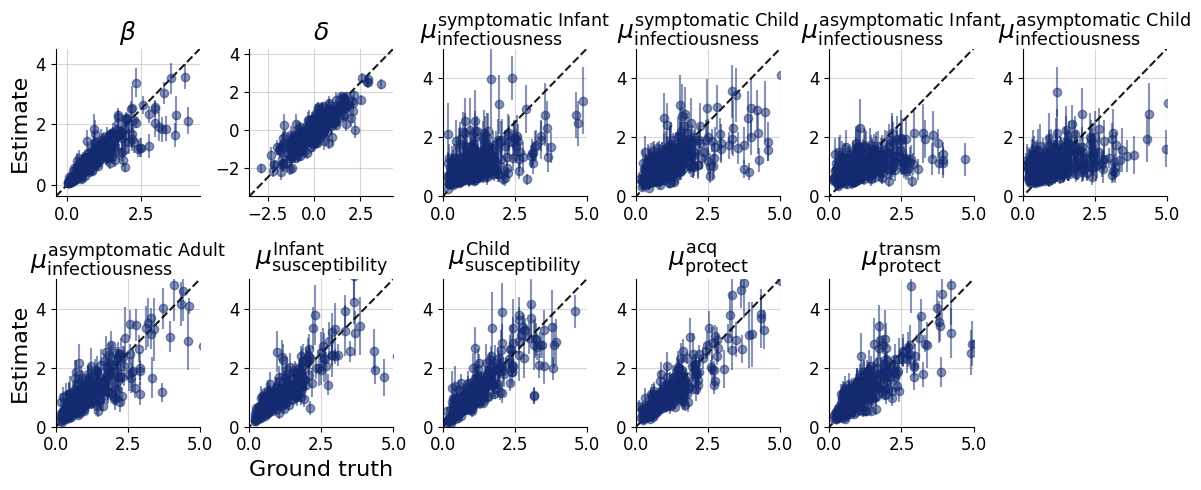

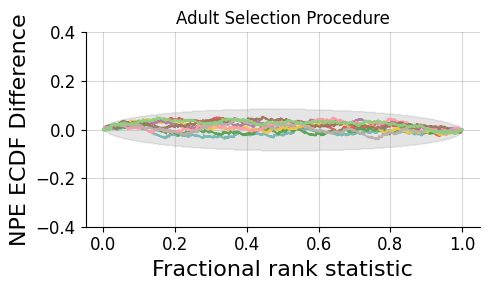

In [21]:
for vd in [validation_data_random, validation_data_pedcov, validation_data_adultcov]:
    print(f"Validation data shape: {vd['selection_procedure'][0]}")
    posterior_samples = workflow.sample(num_samples=1000, conditions=vd)

    fig = bf.diagnostics.recovery(posterior_samples, vd, variable_names=list(param_names.values()),
                                  add_corr=False, figsize=(12, 5))
    ax = fig.get_axes()
    for i, a in enumerate(ax):
        if i != 7:
            a.set_xlabel("")
        if i > 1:
            a.set_xlim(0, 5)
            a.set_ylim(0, 5)
    plt.tight_layout()
    #fig.savefig(f'plots/{scenario_name}_recovery_npe_{vd["selection_procedure"][0]}.pdf', bbox_inches='tight')
    plt.show()

    fig = bf.diagnostics.calibration_ecdf(posterior_samples, vd, variable_names=list(param_names.values()),
                                          stacked=stacked, difference=True, figsize=(12, 5) if not stacked else (5, 3))
    ax = fig.get_axes()
    for i, a in enumerate(ax):
        a.get_legend().remove()
        if not stacked:
            if i != 7:
                a.set_xlabel("")
        else:
            lines = a.get_lines()
            for idx, line in enumerate(lines):
                if list(param_names.keys())[idx] in ['beta', 'delta']:
                    line.remove()
                line.set_color(colors[idx])
                line.set_label(f'{list(param_names.values())[idx]}')
        a.set_ylim(-0.4, 0.4)
        a.set_title(titles[vd['selection_procedure'][0]])
        a.set_ylabel("NPE ECDF Difference")
    plt.tight_layout()
    #fig.savefig(f'plots/{scenario_name}_ecdf_npe_{vd["selection_procedure"][0]}.pdf', bbox_inches='tight')
    plt.show()

# Apply trained model to real data

In [22]:
# create test data to validate code
# test_params = prior("alpha")
# test_df = simulator_alpha(**test_params, return_df=True)['sim_data_df']
# test_df.to_csv('PedCov/data/test_data_alpha.txt', sep=' ', index=False)
#
# test_params = prior("omicron")
# test_df = simulator_omicron(**test_params, return_df=True)['sim_data_df']
# test_df.to_csv('PedCov/data/test_data_omicron.txt', sep=' ', index=False)

In [23]:
# specify the PedCov path
data_path_alpha = 'PedCov/data/test_data_alpha.txt'  # todo: exchange with real PedCov
data_path_omicron = 'PedCov/data/test_data_omicron.txt'
num_samples = 1000

results_file = f'plots/{scenario_name}_real_posterior_samples.pickle'

In [24]:
if os.path.exists(results_file):
    # load results
    with open(results_file, 'rb') as f:
        real_data_results = pickle.load(f)
    print("Loaded real data results from file")
else:
    # load the PedCov
    dfs = {
        'alpha': pd.read_csv(data_path_alpha, delimiter=' ') if data_path_alpha is not None else None,
        'omicron': pd.read_csv(data_path_omicron, delimiter=' ') if data_path_omicron is not None else None
    }

    # patient id in household
    dfs['alpha']['id_patient'] = dfs['alpha'].groupby("id_hh").cumcount() + 1  # Row number within id_hh
    if data_path_omicron is not None:
        dfs['omicron']['id_patient'] = dfs['omicron'].groupby("id_hh").cumcount() + 1

    real_data_results = {
        'alpha': None,
        'omicron': None
    }

    # prepare the PedCov for neural networks
    for variant in variants:
        if variant == 'alpha':
            simulator_bf = simulator_alpha
        else:
            simulator_bf = simulator_omicron
        household_data = normalize_household_data(dfs[variant])[np.newaxis]
        real_data_results[variant] = {
            'sim_data': household_data,
            'selection_procedure': ['pedcov'],
            'selection_procedure_id': [1],  # pedcov
            'variant': [variant],
            'variant_id': [0] if variant == 'alpha' else [1],  # 0 for alpha, 1 for omicron
        }

    # get posterior samples
    for variant in variants:
        print(f"Variant: {variant}")
        if variant == 'alpha':
            simulator_bf = simulator_alpha
        else:
            simulator_bf = simulator_omicron

        posterior_samples_real = workflow.sample(conditions=real_data_results[variant], num_samples=num_samples)
        real_data_results[variant]['posterior_samples'] = posterior_samples_real

        stan_posterior_samples = get_stan_posterior(dfs[variant], param_names, simulator_bf, show_progress=True,
                                                    alpha=0.001 if variant == 'alpha' else 0.01)

        # thin samples to num_samples
        sample_idx = np.random.choice(len(stan_posterior_samples[list(param_names.keys())[0]]), num_samples)
        for p in param_names.keys():
            stan_posterior_samples[p] = stan_posterior_samples[p][sample_idx].reshape(1, num_samples, 1)  # select samples
        real_data_results[variant]['stan_posterior_samples'] = stan_posterior_samples

    # save samples
    with open(results_file, 'wb') as f:
         pickle.dump(real_data_results, f)

Loaded real data results from file


In [25]:
# # plot posterior samples vs prior
# for variant in variants:
#     print(f"Variant: {variant}")
#     fig = bf.diagnostics.pairs_posterior(
#         estimates=real_data_results[variant]['posterior_samples'],
#         variable_keys=list(param_names.keys()),
#         variable_names=list(param_names.values()),
#         label_fontsize=22,
#         legend_fontsize=24
#     )
#     #plt.savefig(f'plots/{scenario_name}_real_posterior_{variant}.pdf', bbox_inches='tight')
#     plt.show()
#
#     fig = bf.diagnostics.pairs_posterior(
#         estimates=real_data_results[variant]['stan_posterior_samples'],
#         variable_keys=list(param_names.keys()),
#         variable_names=list(param_names.values()),
#         label_fontsize=22,
#         legend_fontsize=24
#     )
#     #plt.savefig(f'plots/{scenario_name}_real_stan_posterior_{variant}.pdf', bbox_inches='tight')
#     plt.show()

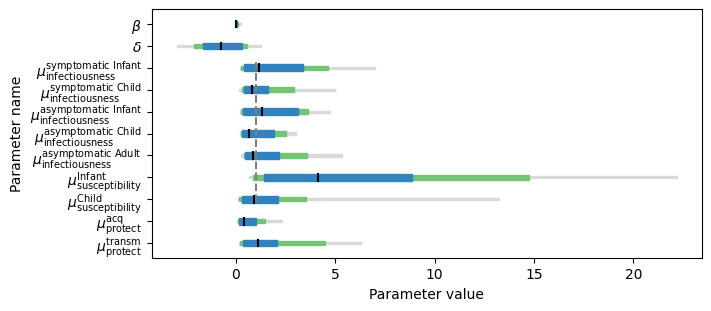

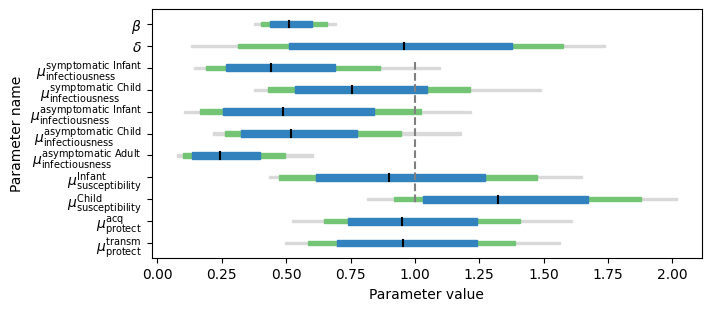

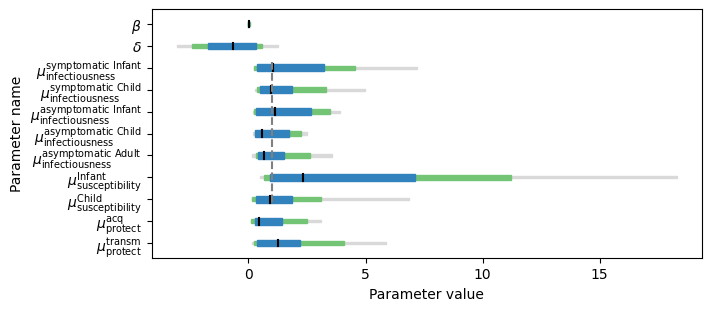

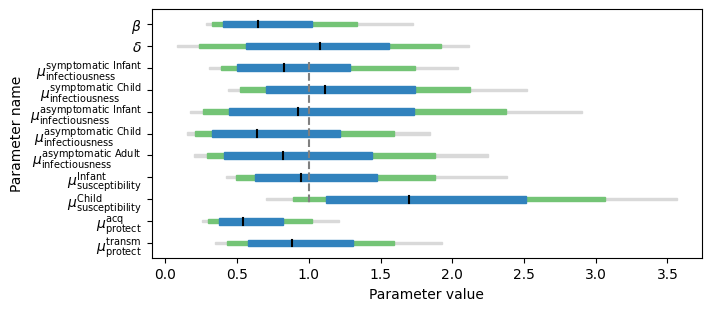

In [26]:
# plot credible intervals for each parameter and each variant
for variant in variants:
    posterior_samples = np.stack([real_data_results[variant]['posterior_samples'][p][0, :, 0]
                                  for p in param_names.keys()], axis=-1)
    ax = sampling_parameter_cis(posterior_samples, alpha=[99, 95, 80], size=(7,3),
                                param_names=list(param_names.values()), title=f"Real Data NPE Posterior CIs - {variant}")
    # add vertical line at 1 for the mu parameters
    ax.vlines(1, ymin=1.75, ymax=8.25, color='grey', linestyle='--')
    ax.set_title("")
    ax.legend().remove()
    #plt.savefig(f'plots/{scenario_name}_real_CIs_{variant}.pdf', bbox_inches='tight')
    plt.show()

    stan_posterior_samples = np.stack([real_data_results[variant]['stan_posterior_samples'][p][0, :, 0]
                                       for p in param_names.keys()], axis=-1)
    ax = sampling_parameter_cis(stan_posterior_samples, alpha=[99, 95, 80], size=(7,3),
                                param_names=list(param_names.values()), title=f"Real Data STAN Posterior CIs - {variant}")
    # add vertical line at 1 for the mu parameters
    ax.vlines(1, ymin=1.75, ymax=8.25, color='grey', linestyle='--')
    ax.set_title("")
    ax.legend().remove()
    #plt.savefig(f'plots/{scenario_name}_real_stan_CIs_{variant}.pdf', bbox_inches='tight')
    plt.show()

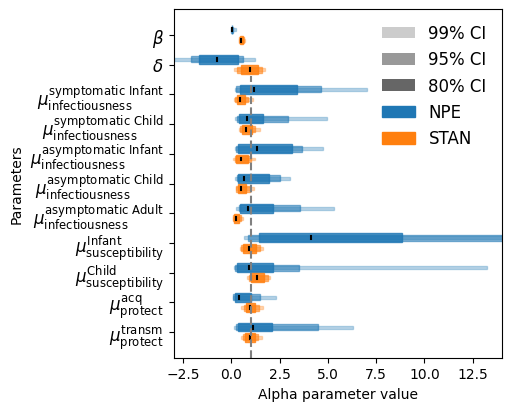

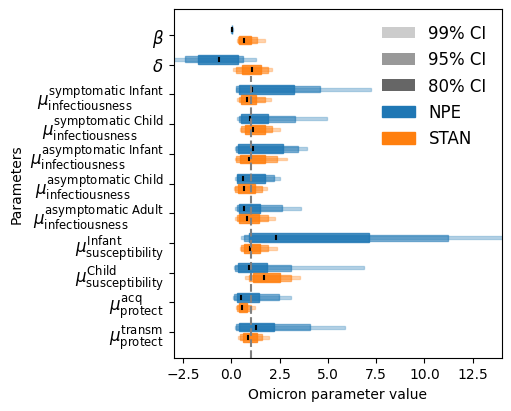

In [49]:
for variant in variants:
    # samples = {key: np.zeros((1, num_samples, 1)) for key in param_names}
    # for i in range(num_samples):
    #     p = prior(variant)
    #     for key in samples:
    #         samples[key][0, i, 0] = p[key]
    # real_data_results[variant]['prior'] = samples

    ax = sampling_parameter_cis_comparison(
        results=real_data_results[variant],
        methods={'posterior_samples': 'NPE', 'stan_posterior_samples': 'STAN'}, #, 'prior': 'Prior'},
        variant=variant,
        param_dict=param_names,
        alpha=[99, 95, 80],
        size=(5, 4),
        show_legend=True
    )
    ax.set_xlim(-3, 14)
    #plt.savefig(f'plots/{scenario_name}_real_CIs_{variant}.pdf', bbox_inches='tight')
    plt.show()